In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
# from sklearn.preprocessing import StandardScaler
from util import concat_hrf, group_by_dict_fields
import os
import globals as gl
from pcm_models import find_model, make_planning_models, make_execution_models
import PcmPy as pcm
from scipy.stats import linregress, t, permutation_test
from statsmodels.stats.anova import AnovaRM
import pickle
import pingouin as pg
from matplotlib import colormaps as cm
# from vis import add_significant_patches_to_ml_rois, add_lineplot_to_boxplot, add_significance_bars, set_spines_and_ticks_width, add_noise_ceiling, make_yref, load_border_vertices_xml
from scipy.stats import ttest_1samp, pearsonr, ttest_rel
from matplotlib.patches import ConnectionPatch, Rectangle, Patch
from matplotlib.lines import Line2D
import os
import globals as gl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nibabel as nb
import numpy as np
import nitools as nt
from matplotlib.colors import LinearSegmentedColormap
import pyvista as pv
from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_1samp

import nitools as nt

plt.style.use('default')

In [3]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

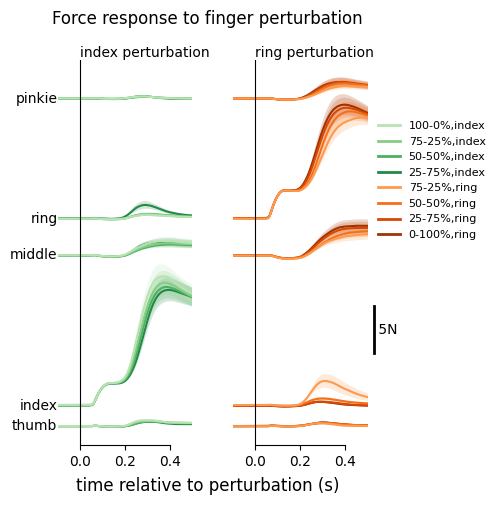

In [4]:
from vis import plot_force_aligned, add_sig_comp_bayes

experiment = 'smp2'
npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())
force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']
fig, axs = plt.subplots(1, 2, figsize=(4, 5), sharey=True, sharex=True)
plot_force_aligned(fig, axs, force, descr)
plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue 20.7316 3.0000 39.0000 0.0000

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  7.4148 3.0000 39.0000 0.0005



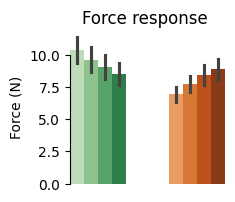

In [5]:
from vis import plot_force_binned

fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
filepath = os.path.join(gl.baseDir, experiment, gl.behavDir, f'{experiment}_force_single_trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat.groupby(['sn', 'cue', 'stimFinger', 'GoNogo', ]).mean(numeric_only=True).reset_index()
fig, axs = plot_force_binned(fig, axs, dat, y=['index1', 'ring1'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 10)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Force response')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='index'], depvar='index1', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

rmANOVA index
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  3.4133 4.0000 52.0000 0.0149

rmANOVA ring
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
cue  6.0417 4.0000 52.0000 0.0005



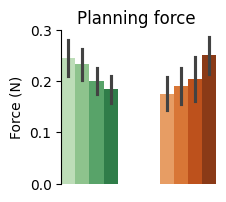

In [6]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_force_binned(fig, axs, dat, y=['index0', 'ring0'])
axs[0].spines[['left']].set_bounds(0, .3)
axs[0].set_ylabel('Force (N)')
fig.suptitle('Planning force')

anova_index = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='index0', subject='sn', within=['cue'])
anova_ring = AnovaRM(data=dat[dat['stimFinger']=='nogo'], depvar='ring0', subject='sn', within=['cue'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

[]

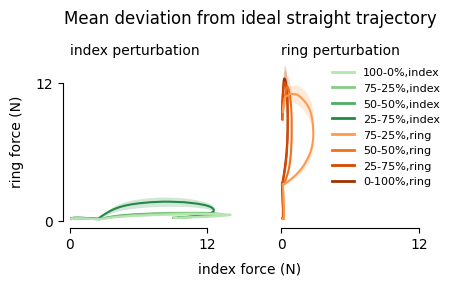

In [7]:
from vis import plot_dev_aligned

fig, axs = plt.subplots(1, 2, figsize=(5, 2.75), sharey=True, sharex=True)
plot_dev_aligned(fig, axs, force, descr)

plt.plot()

rmANOVA index
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond 17.8907 1.0000 13.0000 0.0010

rmANOVA ring
                 Anova
           F Value Num DF  Den DF Pr > F
----------------------------------------
correspond  6.7472 1.0000 13.0000 0.0221



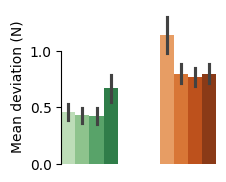

In [8]:
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(2, 2))
fig, axs = plot_force_binned(fig, axs, dat, y=['MD', 'MD'], finger=('index', 'ring'))
axs[0].spines[['left']].set_bounds(0, 1)
axs[0].set_ylabel('Mean deviation (N)')
dat_stat = dat.copy()
dat_stat['correspond'] = 'high'
mask_low = ((dat_stat['cue'] == '75-25%') & (dat_stat['stimFinger'] == 'ring')) | ((dat_stat['cue'] == '25-75%') & (dat_stat['stimFinger'] == 'index'))
dat_stat.loc[mask_low, 'correspond'] = 'low'
dat_stat = dat_stat[dat_stat['GoNogo'] == 'go']

dat_stat = dat_stat.groupby(['sn', 'stimFinger', 'GoNogo','correspond']).mean(numeric_only=True).reset_index()

anova_index = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='index'], depvar='index1', subject='sn', within=['correspond'])
anova_ring = AnovaRM(data=dat_stat[dat_stat['stimFinger']=='ring'], depvar='ring1', subject='sn', within=['correspond'])

result = anova_index.fit()
print('rmANOVA index')
print(result)

result = anova_ring.fit()
print('rmANOVA ring')
print(result)

plt.show()

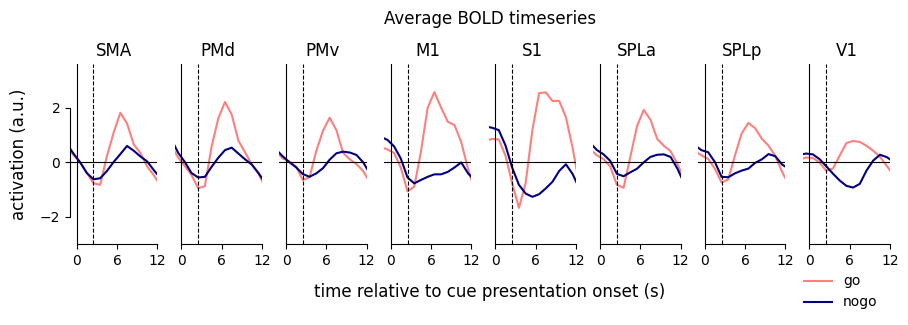

In [9]:
from vis import plot_bold

H = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
sns = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
Ts = [os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', 'T.mat') for sn in sns]
T = concat_hrf(Ts)

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(10, 3))
fig, axs = plot_bold(fig, axs, T, H, rois)

plt.show()

/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


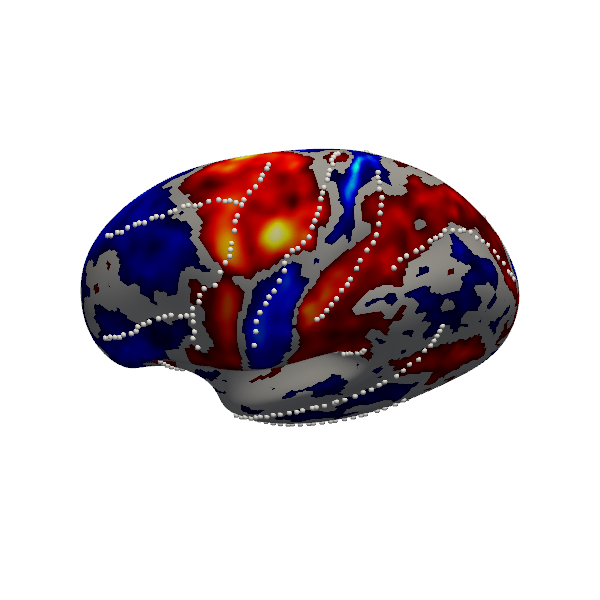

In [10]:
from vis import plot_surf

dtype = 'con'
H = 'L'
thresh = 1
vmin, vmax = -15, 15
cold_colors = [(0, 0, 0), (0, 0, 1), (0, 1, 1), (1, 1, 1)]  # RGB tuples
cold = LinearSegmentedColormap.from_list('cold_custom', cold_colors, N=128)
hot = plt.cm.hot(np.linspace(0, 1, 128))
cold_vals = cold(np.linspace(1, 0, 128))  # reversed
combined = np.vstack((cold_vals, hot))
cmap = LinearSegmentedColormap.from_list('coldhot', combined)
cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'glm{glm}.{dtype}.plan-exec.smooth.dscalar.nii'))
p = pv.Plotter(window_size=(600, 600))
p = plot_surf(p, cifti, H, cmap=cmap, col=0, thresh=thresh, vmin=vmin, vmax=vmax)
p.view_vector((-.8, 0, 1))
p.show()

/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


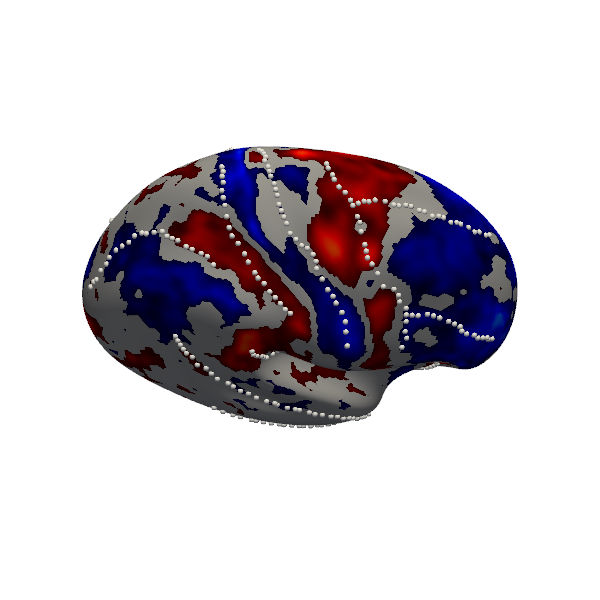

In [11]:
p = pv.Plotter(window_size=(600, 600))
p = plot_surf(p, cifti, 'R', cmap=cmap, col=0, thresh=thresh, vmin=vmin, vmax=vmax)
p.view_vector((.8, 0, 1))
p.show()

/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


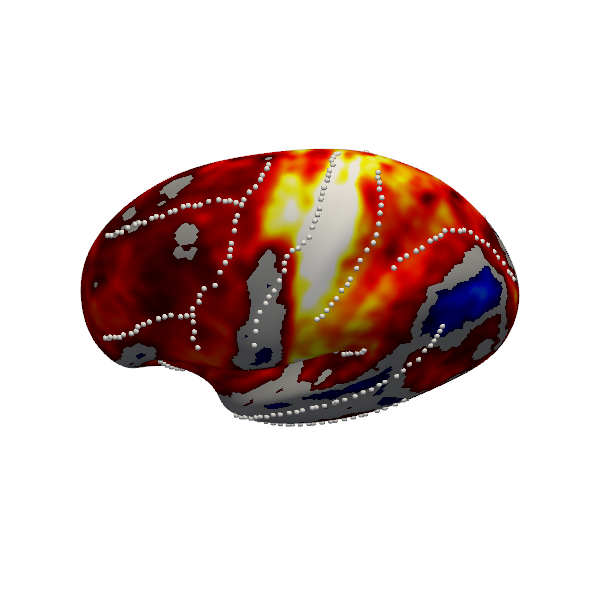

In [12]:
p = pv.Plotter(window_size=(600, 600))
p = plot_surf(p, cifti, 'L', cmap=cmap, col=1, thresh=thresh, vmin=vmin, vmax=vmax)
p.view_vector((-.8, 0, 1))
p.show()

/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


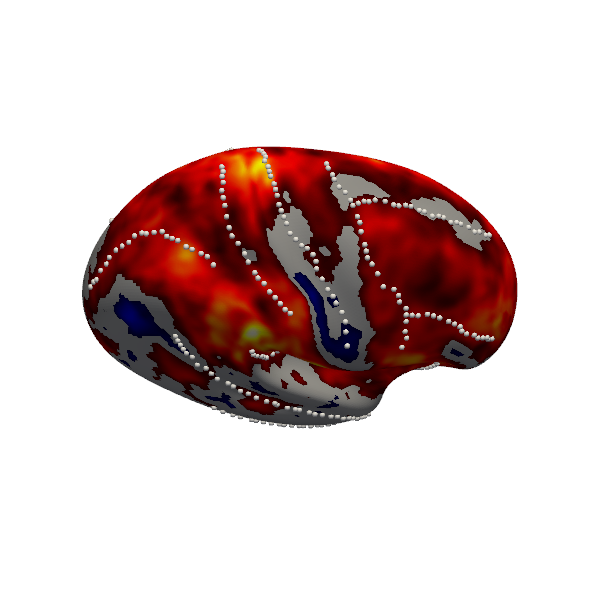

In [13]:
p = pv.Plotter(window_size=(600, 600))
p = plot_surf(p, cifti, 'R', cmap=cmap, col=1, thresh=thresh, vmin=vmin, vmax=vmax)
p.view_vector((.8, 0, 1))
p.show()

ROI: SMA
planning vs. execution: TtestResult(statistic=np.float64(0.8024403626750395), pvalue=np.float64(0.4367228068671992), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(3.1092136377088915), pvalue=np.float64(0.008298280551127385), df=np.int64(13))
execution vs. 0: TtestResult(statistic=np.float64(3.51188358507355), pvalue=np.float64(0.0038258763485076227), df=np.int64(13))
ROI: PMd
planning vs. execution: TtestResult(statistic=np.float64(0.4836842568080278), pvalue=np.float64(0.6366553764567955), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(3.969003198935676), pvalue=np.float64(0.0016030280845840258), df=np.int64(13))
execution vs. 0: TtestResult(statistic=np.float64(4.378284488120725), pvalue=np.float64(0.0007469644422947125), df=np.int64(13))
ROI: PMv
planning vs. execution: TtestResult(statistic=np.float64(0.6475455695410888), pvalue=np.float64(0.5285491939388429), df=np.int64(13))
planning vs. 0: TtestResult(statistic=np.float64(2.6257315

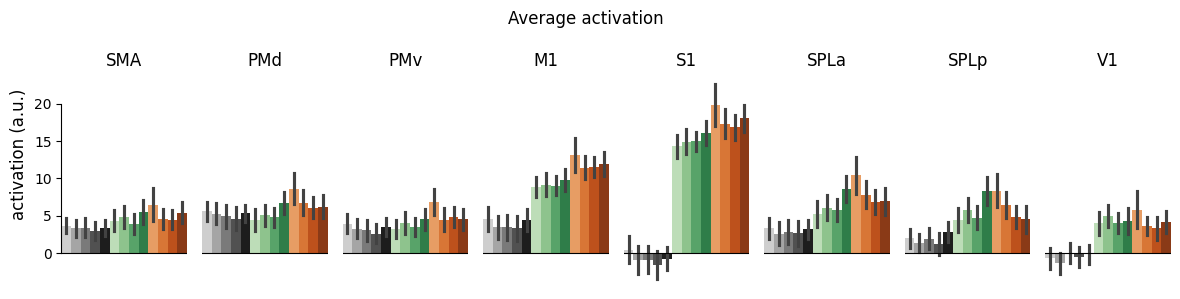

In [14]:
from vis import plot_avg_activation

df_con = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}','ROI.con.avg.tsv'), sep='\t')
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(12, 3))
fig, axs = plot_avg_activation(fig, axs, df_con, H, rois)
df_con_stat = df_con.groupby(['sn', 'roi', 'Hem', 'epoch']).mean(numeric_only=True).reset_index()
for roi in rois:
    plan = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'plan')]['con']
    exec = df_con_stat[(df_con_stat['roi'] == roi) & (df_con_stat['Hem'] == H) & (df_con_stat['epoch'] == 'exec')]['con']
    print(f'ROI: {roi}')
    print(f'planning vs. execution: {ttest_rel(exec, plan)}')
    print(f'planning vs. 0: {ttest_1samp(plan, 0)}')
    print(f'execution vs. 0: {ttest_1samp(exec, 0)}')
fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average activation')
fig.tight_layout()

In [15]:
# experiment = 'smp0'
#
# components = ['finger', 'cue', 'surprise']
#
# epochs = ['Pre', 'SLR', 'LLR', 'Vol']
#
# M = make_execution_models()
# M, _ = find_model(M, 'component')
# G = M.Gc
# MF = pcm.model.ModelFamily(G, comp_names=components, basecomponents=np.eye(8)[None,:,:])
#
# fig, axs = plt.subplots(1, len(epochs), figsize=(5, 2), sharey=True, constrained_layout=True)
#
# for r, epoch in enumerate(epochs):
#     T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.emg.{epoch}.p'))
#     plt.sca(axs[r])
#     c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
#     bars = pcm.vis.plot_component(c_bf, type='bf',palette=['#D4AF37', 'red', 'magenta'])
#
#     for i, col in enumerate(c_bf.columns):
#         vals = c_bf[col].dropna().values
#         vals = vals[np.isfinite(vals)]
#         n = len(vals)
#         if n < 2:
#             continue
#
#         _, p_val_1samp = ttest_1samp(vals, 0, alternative='greater')
#
#         mean = vals.mean()
#         sem = vals.std(ddof=1) / (n**0.5)
#         ci = t.ppf(0.975, df=n-1) * sem  # 95% CI
#         bar_height = mean + ci
#
#         if p_val_1samp < 0.001:
#             stars = '***'
#         elif p_val_1samp < 0.01:
#             stars = '**'
#         elif p_val_1samp < 0.05:
#             stars = '*'
#         else:
#             stars = None
#
#         if stars:
#             axs[r].text(i, bar_height, stars, ha='center', va='bottom', fontsize=12)
#
#     axs[r].set_title(epoch)
#     axs[r].set_xlabel('')
#     axs[r].set_xticks(axs[r].get_xticks())
#     axs[r].set_xticklabels(components, rotation=60, ha='right')
#     # axs[r].hlines(0, 0, 4, color='w', lw=0.8)
#     axs[r].spines[['top', 'right', 'bottom']].set_visible(False)
#     axs[r].spines[['left', ]].set_bounds(0, 40)
#     axs[r].spines[['left', ]].set_linewidth(2)
#     # axs[r].set_yticks([-.5, 0, 1, 2])
#     axs[r].set_ylim([-5, 50])
#     axs[r].spines[['bottom',]].set_bounds(0, 5)
#     axs[r].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
#     axs[r].tick_params(width=2)
#
# # Define legend handles
# legend_handles = [
#     Patch(facecolor='#FFCC33', edgecolor='black', label='finger'),
#     Patch(facecolor='red', edgecolor='black', label='cue'),
#     Patch(facecolor='magenta', edgecolor='black', label='surprise (absolute prediction error)'),
# ]
#
# # Place legend below the entire figure
# fig.legend(handles=legend_handles,
#            loc='lower center',
#            bbox_to_anchor=(0.5, -0.1),
#            frameon=False,
#            ncol=6,
#            fontsize=10)
#
# fig.suptitle('Component Bayes factor')
#
# fig.tight_layout()
#
# plt.show()

In [16]:
# experiment = 'smp0'
#
# epochs = ['Pre', 'SLR', 'LLR', 'Vol']
#
# components = np.array(['finger', 'cue', 'surprise'])
#
# Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'M.emg.pkl'), 'component')
# n_param_c = Mc.n_param
#
# Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'M.emg.pkl'), 'feature')
# n_param_f = Mf.n_param
#
# fig, axs = plt.subplots(1, len(epochs), figsize=(5, 3), sharey=True, )
#
# inset_axs = []
#
# for e, epoch in enumerate(epochs):
#
#     f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.emg.{epoch}.p'), "rb")
#     params = pickle.load(f)
#     G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.{epoch}.npy'))
#     params_c = params[idxc]
#     params_f = params[idxf]
#
#     # main axes
#     sns.barplot(data=var_expl.T, ax=ax, palette=['#D4AF37', 'red', 'magenta'], errorbar='se')
#     ax.set_title(epoch, pad=10)
#     ax.set_xticks(ax.get_xticks())
#     ax.set_xticklabels(components, rotation=60, ha='right')
#     ax.hlines(0, 0, 3, color='w', lw=0.8)
#     ax.axhline(tr.mean(), color='grey', lw=2, ls=':')
#     ax.axhspan(tr.mean() - tr.std() / np.sqrt(len(tr)), tr.mean() + tr.std() / np.sqrt(len(tr)), color='grey', alpha=.2, lw=0)
#     ax.spines[['top', 'right', 'bottom']].set_visible(False)
#     ax.spines[['left', ]].set_bounds(0, .15)
#     ax.spines[['left', ]].set_linewidth(2)
#     # ax.set_yticks([-.5, 0, 1, 2])
#     ax.set_ylim((0, .18))
#     ax.spines[['bottom',]].set_bounds(0, 4)
#     ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
#     ax.set_ylabel('variance')
#     ax.tick_params(width=2)
#     ax.spines[['top', 'right', 'bottom']].set_visible(False)
#
#     # inset for interaction
#     inset_ax = ax.inset_axes([.85, .8, .15, .4], transform=ax.transAxes)
#     interaction = theta_f[1,:] * theta_f[2,:]
#     inset_ax.bar(0, interaction.mean(), width=.5, facecolor='cyan', yerr=interaction.std() / np.sqrt(len(interaction)), ecolor='dimgrey')
#     inset_ax.spines[['top', 'right', 'bottom']].set_visible(False)
#     inset_ax.spines[['left', ]].set_linewidth(2)
#     inset_ax.set_yticks((0, .01, .02))
#     inset_ax.spines[['left', ]].set_bounds(0, .02)
#     inset_ax.set_ylabel('interaction', fontsize=8)
#     inset_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
#     inset_ax.tick_params(axis='y', width=2, labelsize=8)
#     inset_ax.set_ylim(-.005, .03)
#
#     # t-test against zero for interaction
#     _, p_val_1samp = ttest_1samp(interaction, 0, alternative='greater')
#
#     n = len(interaction)
#     mean = np.abs(interaction.mean())
#     sem = interaction.std() / np.sqrt(len(interaction))
#     bar_height = np.sign(interaction.mean()) * (mean + sem) * 1
#
#     if p_val_1samp < 0.001:
#         stars = '***'
#     elif p_val_1samp < 0.01:
#         stars = '**'
#     elif p_val_1samp < 0.05:
#         stars = '*'
#     else:
#         stars = None
#
#     if stars:
#         inset_ax.text(0, bar_height, stars, ha='center', va='bottom', fontsize=12)
#
#     inset_axs.append(inset_ax)
#
# # Define legend handles
# legend_handles = [
#     Patch(facecolor='#D4AF37', edgecolor='black', label='finger'),
#     Patch(facecolor='cyan', edgecolor='black', label='interaction (signed prediction error)'),
#     Patch(facecolor='red', edgecolor='black', label='cue'),
#     Patch(facecolor='magenta', edgecolor='black', label='surprise (unsigned prediction error)'),
# ]
#
# # Place legend below the entire figure
# fig.legend(handles=legend_handles,
#            loc='lower center',
#            bbox_to_anchor=(0.5, -0.1),
#            frameon=False,
#            ncol=1,
#            fontsize=10)
#
# fig.subplots_adjust(bottom=.25, top=.7)
#
# fig.suptitle('Variance explained by component model')
#
# plt.show()

SMA: TtestResult(statistic=np.float64(3.115397692032168), pvalue=np.float64(0.008200080810256239), df=np.int64(13))
PMd: TtestResult(statistic=np.float64(3.450583476019248), pvalue=np.float64(0.0043032966926237915), df=np.int64(13))
PMv: TtestResult(statistic=np.float64(4.124684342372074), pvalue=np.float64(0.0011965439939404705), df=np.int64(13))
M1: TtestResult(statistic=np.float64(2.816644630459623), pvalue=np.float64(0.014558304517772251), df=np.int64(13))
S1: TtestResult(statistic=np.float64(4.319123346999053), pvalue=np.float64(0.0008332360087349522), df=np.int64(13))
SPLa: TtestResult(statistic=np.float64(3.338520439941805), pvalue=np.float64(0.005337234505746158), df=np.int64(13))
SPLp: TtestResult(statistic=np.float64(3.8359436349297704), pvalue=np.float64(0.002061758199099973), df=np.int64(13))
V1: TtestResult(statistic=np.float64(3.899713418996844), pvalue=np.float64(0.0018271611127679925), df=np.int64(13))


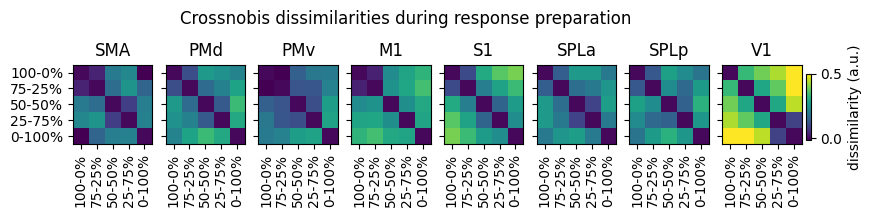

In [17]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .5

fig, axs = plt.subplots(1, len(rois), figsize=(8, 2),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_dissimilarities(fig, axs, r, G, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.006, bbox.y1 - bbox.y0])
im = axs[-1].images[0]
fig.colorbar(im, cax=cbar_ax).set_label('dissimilarity (a.u.)', )
fig.suptitle('Crossnobis dissimilarities during response preparation')

plt.show()

ROI: SMA, tval=3.2402735884402616, pval=0.0032239106467917777, 0.49812298231033586 upper noise
ROI: PMd, tval=2.403953352824657, pval=0.015924210890246628, 0.7269219411232175 upper noise
ROI: PMv, tval=2.5786858293595456, pval=0.01145680455485446, 0.5217734817809188 upper noise
ROI: M1, tval=2.090422465608905, pval=0.02839534431206086, 0.7090060977580008 upper noise
ROI: S1, tval=2.8993775441549228, pval=0.0062113754663577275, 0.9376312993656494 upper noise
ROI: SPLa, tval=1.847949783892601, pval=0.04374131725634959, 0.8591001545958421 upper noise
ROI: SPLp, tval=3.048494250253148, pval=0.004663481009674072, 0.8044270404239383 upper noise
ROI: V1, tval=2.9637358484336644, pval=0.005489104556689402, 0.8643758938949961 upper noise


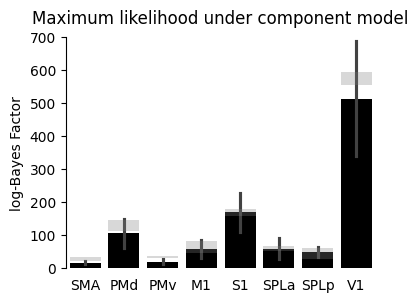

In [18]:
from vis import plot_likelihood

LL = {'roi': [],'noise_upper': [],'noise_lower': [],'baseline': [],'likelihood': [],}
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{H}.{roi}.p'))
    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

fig, axs = plt.subplots(figsize=(4, 3))
fig, axs = plot_likelihood(fig, axs, LL, x='roi')
axs.set_ylim(0, 700)
axs.set_title('Maximum likelihood under component model', pad=10)
plt.show()


SMA:
cue, tval=1.3234838733453136, pval=0.10423940680398208
uncertainty, tval=3.289634479922843, pval=0.0029317502626668578

PMd:
cue, tval=3.2636317111634936, pval=0.003082182255764201
uncertainty, tval=4.7860666098050695, pval=0.00017780982519925945

PMv:
cue, tval=2.448540074620318, pval=0.014646615032568415
uncertainty, tval=2.552723390338354, pval=0.01203413413680442

M1:
cue, tval=3.0428070361382735, pval=0.004714792278142219
uncertainty, tval=2.3823924022956686, pval=0.016579661442354822

S1:
cue, tval=7.6520656190485425, pval=1.813034081578061e-06
uncertainty, tval=2.5552820858384075, pval=0.011976007674595855

SPLa:
cue, tval=2.983545578369199, pval=0.005284011231275241
uncertainty, tval=2.9533509626577557, pval=0.00559975349537029

SPLp:
cue, tval=3.2227832722596226, pval=0.00333429932835804
uncertainty, tval=5.121504437657591, pval=9.810484827668366e-05

V1:
cue, tval=7.4722966850251495, pval=2.34088249355057e-06
uncertainty, tval=4.65762259942767, pval=0.000224143745750437

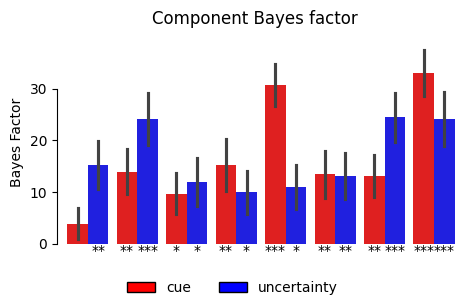

In [19]:
from vis import plot_comp_bayes, add_sig_comp_bayes

components = ['cue', 'uncertainty']
palette = ['red', 'blue']
Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.p'), 'component')
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components, basecomponents=None)
G = Mc.Gc
MF = pcm.model.ModelFamily(G, comp_names=components, basecomponents=None)
fig, axs = plt.subplots(1, len(rois), figsize=(5, 3), sharex=True, sharey=True, )
for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.plan.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    fig, axs = plot_comp_bayes(fig, axs, r, c_bf, components=components, palette=palette)
    print(f'\n{roi}:')
    fig, axs = add_sig_comp_bayes(fig, axs, r, c_bf)

fig.suptitle('Component Bayes factor')
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-3])

fig.subplots_adjust(bottom=.2)
plt.show()

cue, tval=1.3234838733453136, pval=0.10423940680398208
uncertainty, tval=3.289634479922843, pval=0.0029317502626668578

SMA:
cue vs. uncertainty, tval=-1.3956757205071322, pval=0.1861941095805234
cue, tval=3.2636317111634936, pval=0.003082182255764201
uncertainty, tval=4.7860666098050695, pval=0.00017780982519925945

PMd:
cue vs. uncertainty, tval=-1.4261800870109422, pval=0.17738721828200224
cue, tval=2.448540074620318, pval=0.014646615032568415
uncertainty, tval=2.552723390338354, pval=0.01203413413680442

PMv:
cue vs. uncertainty, tval=-0.43179973686429846, pval=0.6729621896296627
cue, tval=3.0428070361382735, pval=0.004714792278142219
uncertainty, tval=2.3823924022956686, pval=0.016579661442354822

M1:
cue vs. uncertainty, tval=1.5897962004650392, pval=0.13589532111187574
cue, tval=7.6520656190485425, pval=1.813034081578061e-06
uncertainty, tval=2.5552820858384075, pval=0.011976007674595855

S1:
cue vs. uncertainty, tval=2.768082056192951, pval=0.015976047467711186
cue, tval=2.9835

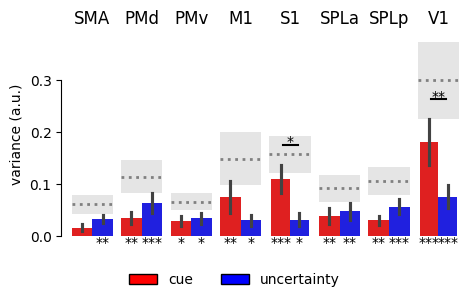

In [20]:
from vis import plot_var_expl, add_sig_var_expl

n_param_c = Mc.n_param
fig, axs = plt.subplots(1, len(rois), figsize=(5, 3), sharey=True, )
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_var_expl(fig, axs, r, G, param_c, components=components, palette=palette)
for r, roi in enumerate(rois):
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    param = pickle.load(f)
    param_c = param[idxc][:n_param_c]
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.plan.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood, method='AIC', format='DataFrame')
    fig, axs = add_sig_comp_bayes(fig, axs, r, c_bf)
    print(f'\n{roi}:')
    fig, axs = add_sig_var_expl(fig, axs, r, param_c, components)
    axs[r].set_title(roi)
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
fig.subplots_adjust(bottom=.2)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[0], axs[0].get_yticks()[-2])
plt.show()

Likelihood od cue model
tval=2.4601259124512476, pval=0.014331091593496511
0.93 noise ceiling
force: TtestResult(statistic=np.float64(3.2106057951069467), pvalue=np.float64(0.006826772009600081), df=np.int64(13))


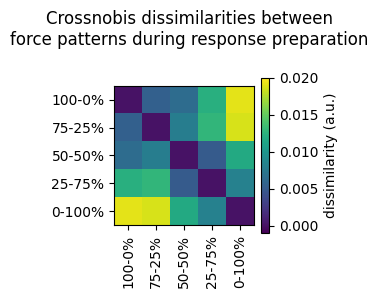

In [21]:
fig, ax = plt.subplots(figsize=(2, 3))

vmin, vmax = -.001, .02

T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.force.plan.p'))

bf_cue = T_cv.likelihood['cue'] - T_cv.likelihood['null']
bf_noise = T_cv.likelihood['ceil'] - T_cv.likelihood['null']

tval, pval = ttest_1samp(bf_cue, 0, alternative='greater')
print(f'Likelihood od cue model\ntval={tval}, pval={pval}')
print(f'{bf_cue.mean() / bf_noise.mean():.02f} noise ceiling')

G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.force.plan.npy'))
fig, ax = plot_dissimilarities(fig, ax, None, G, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=True, source='force')
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.05)
cbar.set_label('dissimilarity (a.u.)')

fig.suptitle('Crossnobis dissimilarities between\nforce patterns during response preparation')

plt.show()



In [22]:
rois_sm = ['M1', 'S1', ]
Hem = 'L'
snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
experiment = 'smp2'
glm = 12

features = np.array(['cue', 'uncertainty'])

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.p'), 'component')
n_param = Mf.n_param

df = pd.DataFrame()
diff1, diff2, diff3 = np.zeros(len(snS)), np.zeros(len(snS)), np.zeros(len(snS))
for s, sn in enumerate(snS):
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df, df_tmp])
    diff1[s] = (df[df['cue'] == 39]['index0'].mean() - df[df['cue'] == 93]['index0'].mean() +
                df[df['cue'] == 93]['ring0'].mean() - df[df['cue'] == 39]['ring0'].mean()) / 2
    diff3[s] = (df[df['stimFinger'] == 91999]['index1'].mean() - df[df['stimFinger'] == 99919]['index1'].mean() +
                df[df['stimFinger'] == 99919]['ring1'].mean() - df[df['stimFinger'] == 91999]['ring1'].mean()) / 2
    diff2[s] = dat['forceDiff'].mean()

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(3, 3.5))

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.p'), "rb")
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta_exp = np.exp(theta)
    theta_sqrt = np.sqrt(theta_exp)

    # Regression for diff2
    x = diff2
    y = theta_exp[0]
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = slope * x_fit + intercept

    # Compute confidence intervals
    n = len(x)
    y_pred = slope * x + intercept
    residuals = y - y_pred
    dof = n - 2
    t_val = t.ppf(0.95, dof)

    se_line = np.sqrt(np.sum(residuals**2) / dof * (1/n + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2)))
    ci = t_val * se_line

    # Check confidence interval at x = 0
    ix_0 = np.argmin(np.abs(x_fit - 0))
    lower_bound = y_fit[ix_0] - ci[ix_0]
    upper_bound = y_fit[ix_0] + ci[ix_0]

    MSE = np.sum(residuals**2) / dof
    SE_intercept = np.sqrt(MSE * (1/n + np.mean(x)**2 / np.sum((x - np.mean(x))**2)))
    t_intercept = intercept / SE_intercept
    p = 1 - t.cdf(t_intercept, df=dof)

    if lower_bound > 0:
        print(f"Intercept is significantly > 0 (one-sided, p < 0.05), t={t_intercept}, p={p}")
    else:
        print(f'Intercept not significant')

    axs[r].plot(x_fit, y_fit, color='k', linestyle='--', label='Fit')
    axs[r].fill_between(x_fit, y_fit - ci, y_fit + ci, color='k', alpha=.2, label='95% CI', lw=0)
    axs[r].scatter(x, y, color='k')

    axs[r].axvline(0, lw=.8, color='k')
    axs[r].axhline(0, lw=.8, color='k')

    axs[r].set_title(roi)

    # Remove spines from 'left', 'top', and 'right'
    axs[r].spines['left'].set_bounds(0, .6)
    axs[r].spines['bottom'].set_bounds(0.0, .08)
    axs[r].spines['top'].set_visible(False)
    axs[r].spines['right'].set_visible(False)

    # Set ticks for x-axis and y-axis
    axs[r].set_xticks(np.linspace(0, .08, 2))
    axs[r].tick_params(width=2)

    # Set linewidth for remaining spines ('bottom') and ticks
    axs[r].spines['bottom'].set_linewidth(2)
    axs[r].spines['left'].set_linewidth(2)

fig.supxlabel('finger pre-activation (N)')
fig.supylabel('Cue variance (a.u.)')

fig.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: '/cifs/diedrichsen/data/SensoriMotorPrediction/smp2/pcm/M.plan.glm12.p'

SMA: TtestResult(statistic=np.float64(2.6596039127542586), pvalue=np.float64(0.019649377200109546), df=np.int64(13))
PMd: TtestResult(statistic=np.float64(3.9189436249117895), pvalue=np.float64(0.00176191614620381), df=np.int64(13))
PMv: TtestResult(statistic=np.float64(2.9972126761847764), pvalue=np.float64(0.010293925810650367), df=np.int64(13))
M1: TtestResult(statistic=np.float64(3.4528518356755113), pvalue=np.float64(0.004284600006325672), df=np.int64(13))
S1: TtestResult(statistic=np.float64(3.802236166183732), pvalue=np.float64(0.0021979790575622302), df=np.int64(13))
SPLa: TtestResult(statistic=np.float64(4.707939157753573), pvalue=np.float64(0.0004093091948951081), df=np.int64(13))
SPLp: TtestResult(statistic=np.float64(1.2668782867513393), pvalue=np.float64(0.22742586412346125), df=np.int64(13))
V1: TtestResult(statistic=np.float64(2.697028779168698), pvalue=np.float64(0.018297329001536543), df=np.int64(13))


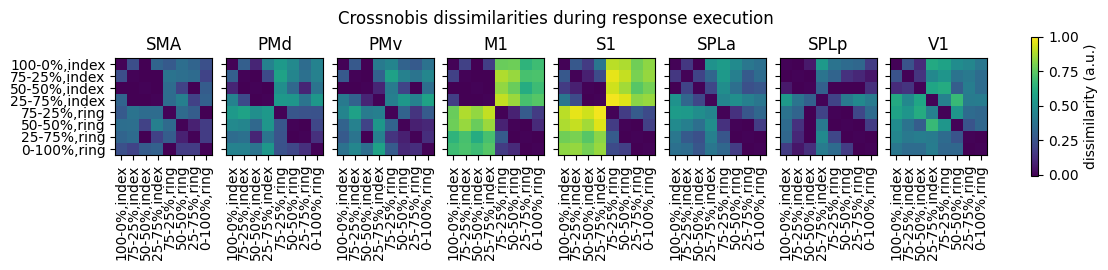

In [24]:
vmin, vmax = -.01, 1

fig, axs = plt.subplots(1, len(rois), figsize=(11, 2.5),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    fig, axs = plot_dissimilarities(fig, axs, r, G, list(gl.regressor_mapping.keys())[5:13], vmin=vmin, vmax=vmax, sqrt=True, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()

ROI: SMA, TtestResult(statistic=np.float64(2.982713928675849), pvalue=np.float64(0.005292466581896409), df=np.int64(13)), 0.08131160210006957 upper noise
ROI: PMd, TtestResult(statistic=np.float64(3.3078672732682763), pvalue=np.float64(0.00283068979184421), df=np.int64(13)), 0.28873955492757053 upper noise
ROI: PMv, TtestResult(statistic=np.float64(5.067343000807844), pvalue=np.float64(0.00010788275837380204), df=np.int64(13)), 0.30038544270420137 upper noise
ROI: M1, TtestResult(statistic=np.float64(3.3418881933765143), pvalue=np.float64(0.0026513900659224294), df=np.int64(13)), 0.7649260931543186 upper noise
ROI: S1, TtestResult(statistic=np.float64(3.4752874777736524), pvalue=np.float64(0.002052020463932941), df=np.int64(13)), 0.8106679166354671 upper noise
ROI: SPLa, TtestResult(statistic=np.float64(5.162764401237307), pvalue=np.float64(9.127945710517659e-05), df=np.int64(13)), 0.32499814161157176 upper noise
ROI: SPLp, TtestResult(statistic=np.float64(2.2844881433509086), pvalue=n

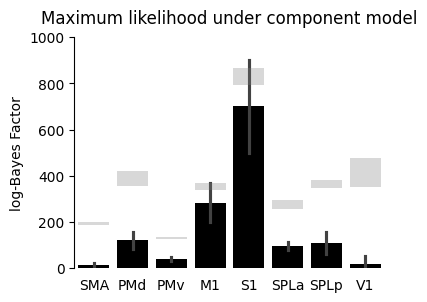

In [25]:
LL = {'roi': [],'noise_upper': [],'noise_lower': [],'baseline': [],'likelihood': [],}
for roi in rois:
    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.exec.glm{glm}.{H}.{roi}.p'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.exec.glm{glm}.{H}.{roi}.p'))
    LL['likelihood'].extend(T_cv.likelihood['component'])
    LL['baseline'].extend(T_cv.likelihood['null'])
    LL['roi'].extend([roi] * len(T_cv.likelihood['component']))
    LL['noise_upper'].extend(T_gr.likelihood['ceil'])
    LL['noise_lower'].extend(T_cv.likelihood['ceil'])

fig, axs = plt.subplots(figsize=(4, 3))
fig, axs = plot_likelihood(fig, axs, LL, x='roi')
axs.set_ylim(0, 1000)
axs.set_title('Maximum likelihood under component model', pad=10)
plt.show()


SMA:
finger, tval=2.618053261177949, pval=0.010632302980762403
cue, tval=0.7354513928597635, pval=0.23756248739386465
surprise, tval=3.7525637582355524, pval=0.001207831755896685

PMd:
finger, tval=5.6838142379809, pval=3.746510921984692e-05
cue, tval=1.2509118196221711, pval=0.1165059592091929
surprise, tval=6.4583523112707875, pval=1.0691520707413233e-05

PMv:
finger, tval=3.447975144481811, pval=0.002162448739585374
cue, tval=-79.5444720775201, pval=1.0
surprise, tval=3.9849550645659297, pval=0.00077777164217192

M1:
finger, tval=16.45130623684004, pval=2.1978078494449755e-10
cue, tval=1.10523223611035, pval=0.14454731720027048
surprise, tval=2.4525642261047427, pval=0.014536273999352683

S1:
finger, tval=67.11620486890071, pval=3.3103785364919754e-18
cue, tval=2.6624449475747167, pval=0.009771704953285295
surprise, tval=3.2993184149508528, pval=0.0028776307760861202

SPLa:
finger, tval=4.299987570496643, pval=0.00043164597062630777
cue, tval=1.8030459355682968, pval=0.047298992674

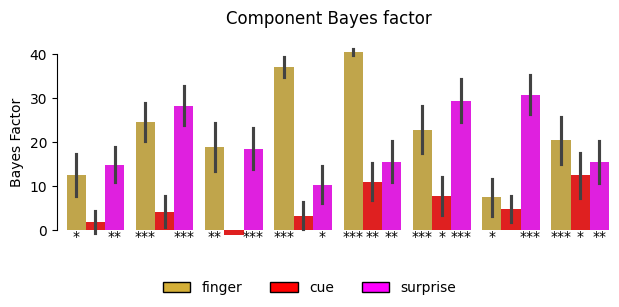

In [31]:
components = ['finger', 'cue', 'surprise']
palette = ['#D4AF37', 'red', 'magenta']
Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.p'), 'component')
MF = pcm.model.ModelFamily(Mc.Gc, comp_names=components, basecomponents=np.eye(Mc.Gc.shape[1])[None, :, :])

fig, axs = plt.subplots(1, len(rois), figsize=(7, 3), sharex=True, sharey=True, )

for r, roi in enumerate(rois):
    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T.model_family.exec.glm{glm}.{H}.{roi}.p'))
    c_bf = MF.component_bayesfactor(T.likelihood,method='AIC',format='DataFrame')
    fig, axs = plot_comp_bayes(fig, axs, r, c_bf, components=components, palette=palette)
    print(f'\n{roi}:')
    fig, axs = add_sig_comp_bayes(fig, axs, r, c_bf)

fig.suptitle('Component Bayes factor')
legend_handles = [Patch(facecolor=col, edgecolor='black', label=comp) for comp, col in zip(components, palette)]
fig.legend(handles=legend_handles, loc='lower center', frameon=False, ncol=len(components), fontsize=10)
axs[0].spines['left'].set_bounds(axs[0].get_yticks()[1], axs[0].get_yticks()[-2])

fig.subplots_adjust(bottom=.2)
plt.show()

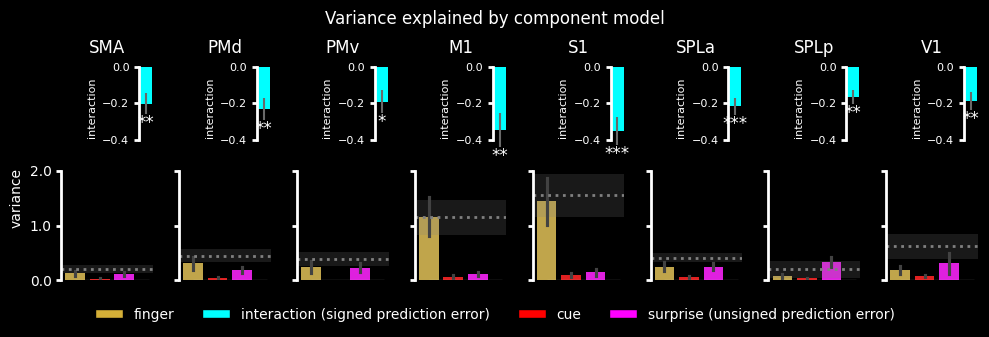

In [64]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

components = np.array(['finger', 'cue', 'surprise'])

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.p'), 'component')
n_param_c = Mc.n_param

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.p'), 'feature')
n_param_f = Mf.n_param

fig, axs = plt.subplots(1, len(rois), figsize=(10, 3), sharey=True, constrained_layout=True)

inset_axs = []

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.p'), "rb")
    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    tr = np.array([np.trace(G) for G in G_obs])

    ax = axs[r]
    params = pickle.load(f)

    # variance explained
    params_c = params[idxc]
    theta_c = params_c[:n_param_c]
    var_expl = np.exp(theta_c)

    # interaction
    params_f = params[idxf]
    theta_f = params_f[:n_param_f]
    interaction = theta_f[1, :] * theta_f[2, :]

    # main axes
    sns.barplot(data=var_expl.T, ax=ax, palette=['#D4AF37', 'red', 'magenta'], errorbar='se')
    ax.set_title(roi, pad=10)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(components, rotation=60, ha='right')
    ax.hlines(0, 0, 3, color='w', lw=0.8)
    ax.axhline(tr.mean(), color='grey', lw=2, ls=':')
    ax.axhspan(tr.mean() - tr.std() / np.sqrt(len(tr)), tr.mean() + tr.std() / np.sqrt(len(tr)), color='grey', alpha=.2, lw=0)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.spines[['left', ]].set_bounds(0, 2)
    ax.spines[['left', ]].set_linewidth(2)
    ax.set_yticks([-.5, 0, 1, 2])
    ax.set_ylim((0, 3))
    ax.spines[['bottom',]].set_bounds(0, 4)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.set_ylabel('variance')
    ax.tick_params(width=2)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)

    # inset for interaction
    inset_ax = ax.inset_axes([.85, .8, .15, .5], transform=ax.transAxes)
    interaction = theta_f[1,:] * theta_f[2,:]
    inset_ax.bar(0, interaction.mean(), width=.5, facecolor='cyan', yerr=interaction.std() / np.sqrt(len(interaction)), ecolor='dimgrey')
    inset_ax.spines[['top', 'right', 'bottom']].set_visible(False)
    inset_ax.spines[['left', ]].set_linewidth(2)
    inset_ax.spines[['left', ]].set_bounds(-.4, 0)
    inset_ax.set_ylabel('interaction', fontsize=8)
    inset_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    inset_ax.tick_params(axis='y', width=2, labelsize=8)
    inset_ax.set_ylim(-.45, 0)

    # t-test against zero for interaction
    _, p_val_1samp = ttest_1samp(interaction, 0, alternative='two-sided')

    n = len(interaction)
    mean = np.abs(interaction.mean())
    sem = interaction.std() / np.sqrt(len(interaction))
    bar_height = np.sign(interaction.mean()) * (mean + sem) * 1

    if p_val_1samp < 0.001:
        stars = '***'
    elif p_val_1samp < 0.01:
        stars = '**'
    elif p_val_1samp < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    if stars:
        inset_ax.text(0, bar_height, stars, ha='center', va='top', fontsize=12)

    inset_axs.append(inset_ax)

# Define legend handles
legend_handles = [
    Patch(facecolor='#D4AF37', edgecolor='black', label='finger'),
    Patch(facecolor='cyan', edgecolor='black', label='interaction (signed prediction error)'),
    Patch(facecolor='red', edgecolor='black', label='cue'),
    Patch(facecolor='magenta', edgecolor='black', label='surprise (unsigned prediction error)'),
]

# Place legend below the entire figure
fig.legend(handles=legend_handles,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=False,
           ncol=6,
           fontsize=10)

fig.tight_layout()

fig.suptitle('Variance explained by component model')


plt.show()

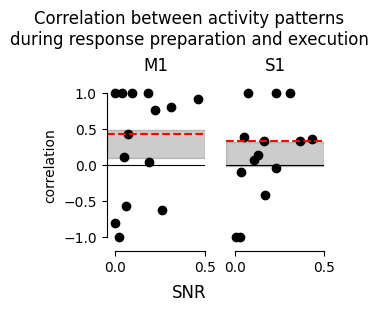

In [10]:
f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)[-1]

rois = ['M1', 'S1']

fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(3, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]

    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_in.corr.glm{glm}.{H}.{roi}.p'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta = pickle.load(f)[-1]

    N = theta.shape[1]

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[-1]

    sigma2_1 = np.exp(theta[0])
    sigma2_2 = np.exp(theta[1])
    r_indiv = Mflex.get_correlation(theta)
    sigma2_e = np.exp(theta[3])
    SNR = np.sqrt(sigma2_1*sigma2_2)/sigma2_e
    ax.scatter(SNR, r_indiv, color='k')

    theta_g,_= pcm.group_to_individ_param(theta_g,Mflex,N)
    r_group = Mflex.get_correlation(theta_g)
    ax.axhline(r_group[0], color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.set_title(roi)

    ax.axhspan(r_indiv.mean() - (r_indiv.std() / np.sqrt(r_indiv.size)),
               r_indiv.mean() + (r_indiv.std() / np.sqrt(r_indiv.size)), alpha=.2, color='k')

    ax.set_ylim(-1.2, 1.2)
    ax.set_xlim(-.05, .5)

    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines[['bottom']].set_bounds(0, .5)
    ax.spines[['left']].set_bounds(-1, 1)

    if r==0:
        ax.spines[['left']].set_visible(True)
    else:
        ax.set_yticks([])

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Correlation between activity patterns\nduring response preparation and execution')

plt.show()


Text(0.02, 0.5, 'log-likelihood')

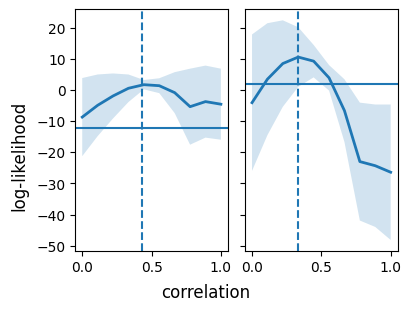

In [12]:
f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan-exec.p'), "rb")
M = pickle.load(f)
nsteps = len(M) - 1

fig, axs = plt.subplots(1, len(rois),figsize=(4, 3), sharex=True, sharey=True, constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]

    # load log-likelihoods
    T_in = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_in.corr.glm{glm}.{H}.{roi}.p'))

    # load params
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_in = pickle.load(f)

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr.glm{glm}.{H}.{roi}.p'), 'rb')
    theta_g = pickle.load(f)[-1]

    N = theta_in[0].shape[1] # N participants

    L = T_in.likelihood.to_numpy()
    L = L - L.mean(axis=1).reshape(-1, 1)
    maxL = L[:,-1]
    L = L[:,0:-1] # Remove flexible model

    L_avg = L.mean(axis=0)
    L_err = L.std(axis=0) / np.sqrt(N)

    maxL_cv = np.empty(N)
    for n in range(N):
        mask = np.delete(np.arange(N), n)
        peak_ind = np.argmax(L[mask, :].mean(axis=0))  # Find best model on N-1 subjects
        maxL_cv[n] = L[n, peak_ind]  # Log-likelihood of that model on left-out subject

    r, tval, pval = (np.empty(nsteps) for _ in range(3))
    for i in range(nsteps):
        r[i] = M[i].corr
        tval[i], pval[i] = ttest_rel(maxL_cv, L[:, i], alternative='greater')

    theta_g,_= pcm.group_to_individ_param(theta_g,M[-1],N)
    maxr = M[-1].get_correlation(theta_g)

    tval0, pval0 = ttest_rel(maxL, L[:, 0], alternative='greater')

    ax.plot(r, L_avg,  lw=2)
    ax.fill_between(r, L_avg - L_err, L_avg + L_err, lw=0, alpha=.2)

    x = np.where(pval < .05)[0]
    if x.size > 0:
        ax.axvspan(r[x[0]], r[x[-1]], color='k', alpha=0.2, lw=0)
    ax.axhline(maxL_cv.mean())
    ax.axvline(maxr.mean(),  ls='--')


fig.supxlabel('correlation')
fig.supylabel('log-likelihood')

Pre: TtestResult(statistic=np.float64(1.2562711351103901), pvalue=np.float64(0.2406464973597068), df=np.int64(9))
SLR: TtestResult(statistic=np.float64(1.85111675759736), pvalue=np.float64(0.09717811789888424), df=np.int64(9))
LLR: TtestResult(statistic=np.float64(3.093028661203683), pvalue=np.float64(0.012866409343342029), df=np.int64(9))
Vol: TtestResult(statistic=np.float64(6.215846247016809), pvalue=np.float64(0.00015587474309000966), df=np.int64(9))


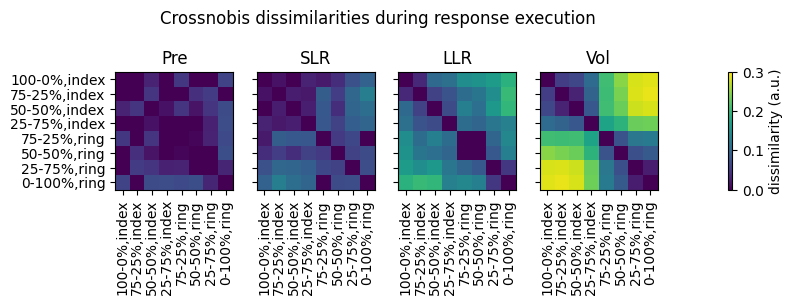

In [35]:
from vis import plot_dissimilarities

experiment = 'smp0'
vmin, vmax = -0., .3
epochs = ['Pre', 'SLR', 'LLR', 'Vol']
fig, axs = plt.subplots(1, 4, figsize=(7, 2.5), sharex=True, sharey=True)
for e, epoch in enumerate(epochs):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.emg.{epoch}.npy'))
    fig, axs = plot_dissimilarities(fig, axs, e, G, list(gl.regressor_mapping.keys())[5:13], vmin=vmin, vmax=vmax, sqrt=True, source=epoch)
    axs[e].set_title(epoch)
bbox = axs[0,].get_position()
cbar_ax = fig.add_axes([1, bbox.y0, 0.006, bbox.y1 - bbox.y0])
im = axs[-1].images[0]
fig.colorbar(im, cax=cbar_ax).set_label('dissimilarity (a.u.)', )
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()